In [50]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies = pd.read_pickle('movies copy.pkl')
cv = CountVectorizer(max_features=500, stop_words='english')
vectors = cv.fit_transform(movies['tags']).toarray()
print('vectors shape:', vectors.shape)
movies.head()

vectors shape: (4803, 500)


,id,title,tags,budget,revenue,popularity,runtime,vote_average,vote_count
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",237000000.0,2.787965e+09,150.437577,162.0,7.2,11800
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",300000000.0,9.610000e+08,139.082615,169.0,6.9,4500
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,245000000.0,8.806746e+08,107.376788,148.0,6.3,4466
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,250000000.0,1.084939e+09,112.312950,165.0,7.6,9106
4,49529,John Carter,"John Carter is a war-weary, former military ca...",260000000.0,2.841391e+08,43.926995,132.0,6.1,2124


In [51]:
similarity = cosine_similarity(vectors)

print("Similarity shape:", similarity.shape)

Similarity shape: (4803, 4803)


In [52]:
def recommend(movie_title):
    if movie_title not in movies['title'].values:
        return "Movie not found in the dataset."
    idx = movies[movies['title'] == movie_title].index[0]
    distances = sorted(enumerate(similarity[idx]), reverse=True, key=lambda x: x[1])
    result = []
    for i in distances[1:6]:
        result.append(movies.iloc[i[0]].title)
    return result

In [53]:
test_movies = [
    'Avatar',
    'The Dark Knight',
    'Interstellar',
    'Toy Story',
    'The Godfather'
]

for title in test_movies:
    print(f"\n🎬 Because you watched: {title}")
    print("─" * 50)
    result = recommend(title)
    print(result)


🎬 Because you watched: Avatar
──────────────────────────────────────────────────
['Independence Day', 'Beowulf', 'The Fifth Element', 'Small Soldiers', 'Aliens vs Predator: Requiem']

🎬 Because you watched: The Dark Knight
──────────────────────────────────────────────────
['The Usual Suspects', "Gangster's Paradise: Jerusalema", "Amidst the Devil's Wings", 'Batman Begins', 'Headhunters']

🎬 Because you watched: Interstellar
──────────────────────────────────────────────────
['Silent Running', 'Gattaca', 'Gravity', 'Lost in Space', "Ender's Game"]

🎬 Because you watched: Toy Story
──────────────────────────────────────────────────
['Over the Hedge', 'Toy Story 2', 'Garfield: A Tail of Two Kitties', "A Bug's Life", 'Stuart Little 2']

🎬 Because you watched: The Godfather
──────────────────────────────────────────────────
['The Godfather: Part II', 'Mi America', 'The Replacement Killers', 'Dom Hemingway', 'Deadfall']


In [54]:
print(recommend('Avatar'))
print(recommend('The Dark Knight'))
print(recommend('Interstellar'))

['Independence Day', 'Beowulf', 'The Fifth Element', 'Small Soldiers', 'Aliens vs Predator: Requiem']
['The Usual Suspects', "Gangster's Paradise: Jerusalema", "Amidst the Devil's Wings", 'Batman Begins', 'Headhunters']
['Silent Running', 'Gattaca', 'Gravity', 'Lost in Space', "Ender's Game"]


In [55]:
import os
os.makedirs('artifacts', exist_ok=True)

pickle.dump(cv,         open('artifacts/vectorizer.pkl', 'wb'))
pickle.dump(similarity, open('artifacts/similarity.pkl', 'wb'))

print("✅ Saved vectorizer and similarity matrix")

✅ Saved vectorizer and similarity matrix


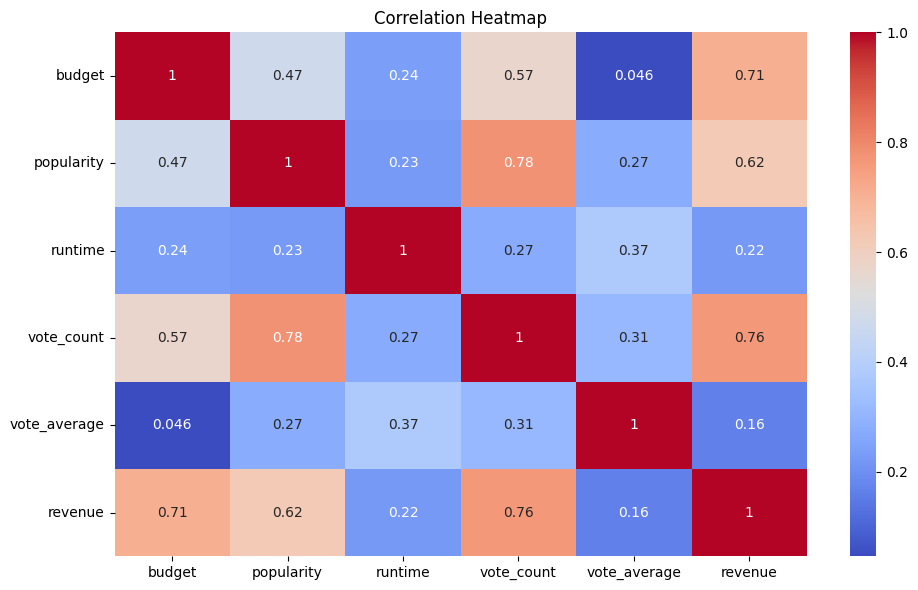

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
features_col= ['budget', 'popularity', 'runtime',  'vote_count', 'vote_average', 'revenue']
corr = movies[features_col].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [57]:
features = ['budget', 'popularity', 'vote_count', 'vote_average']
X = movies[features]
Y = movies['revenue']
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (4803, 4)
Y shape: (4803,)


In [58]:

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (3842, 4)
Test size: (961, 4)


In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model  import LinearRegression
models = { 
    'linear regression': LinearRegression(),
    'xgboost': XGBRegressor( 
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42),

    'gradient boosting': GradientBoostingRegressor(
    n_estimators  = 200,     # more rounds
    max_depth     = 8,       # deeper than before
    learning_rate = 0.08,    # slower but more precise
    subsample     = 0.8,
    min_samples_leaf = 10,
    random_state  = 42
),

    'random forest': RandomForestRegressor(
    n_estimators     = 500,   # more trees = more stable
    max_depth        = 10,     # deeper trees = learns more patterns
    min_samples_leaf = 10,    # reduced from 20
    max_features     = "sqrt",
    random_state     = 42,
    n_jobs           = -1
) 
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    predictions[name] = model.predict(X_test)
    print(f"✅ {name} trained")
    print(f"    Done — Accuracy: {model.score(X_test, Y_test)*100:.2f}%")

✅ linear regression trained
    Done — Accuracy: 73.01%
✅ xgboost trained
    Done — Accuracy: 65.06%
✅ gradient boosting trained
    Done — Accuracy: 72.19%
✅ random forest trained
    Done — Accuracy: 78.76%


In [61]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
models = {
    'Linear Regression': models['linear regression'],
    'XGBoost': models['xgboost'],
    'Gradient Boosting': models['gradient boosting'],
    'Random Forest': models['random forest']
}
for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")
    

Linear Regression - MSE: 6447496404876268.00, MAE: 49106222.44, R²: 0.7301
XGBoost - MSE: 8346471056561612.00, MAE: 44832580.28, R²: 0.6506
Gradient Boosting - MSE: 6642250947024065.00, MAE: 45020318.88, R²: 0.7219
Random Forest - MSE: 5074418441042544.00, MAE: 42112792.09, R²: 0.7876


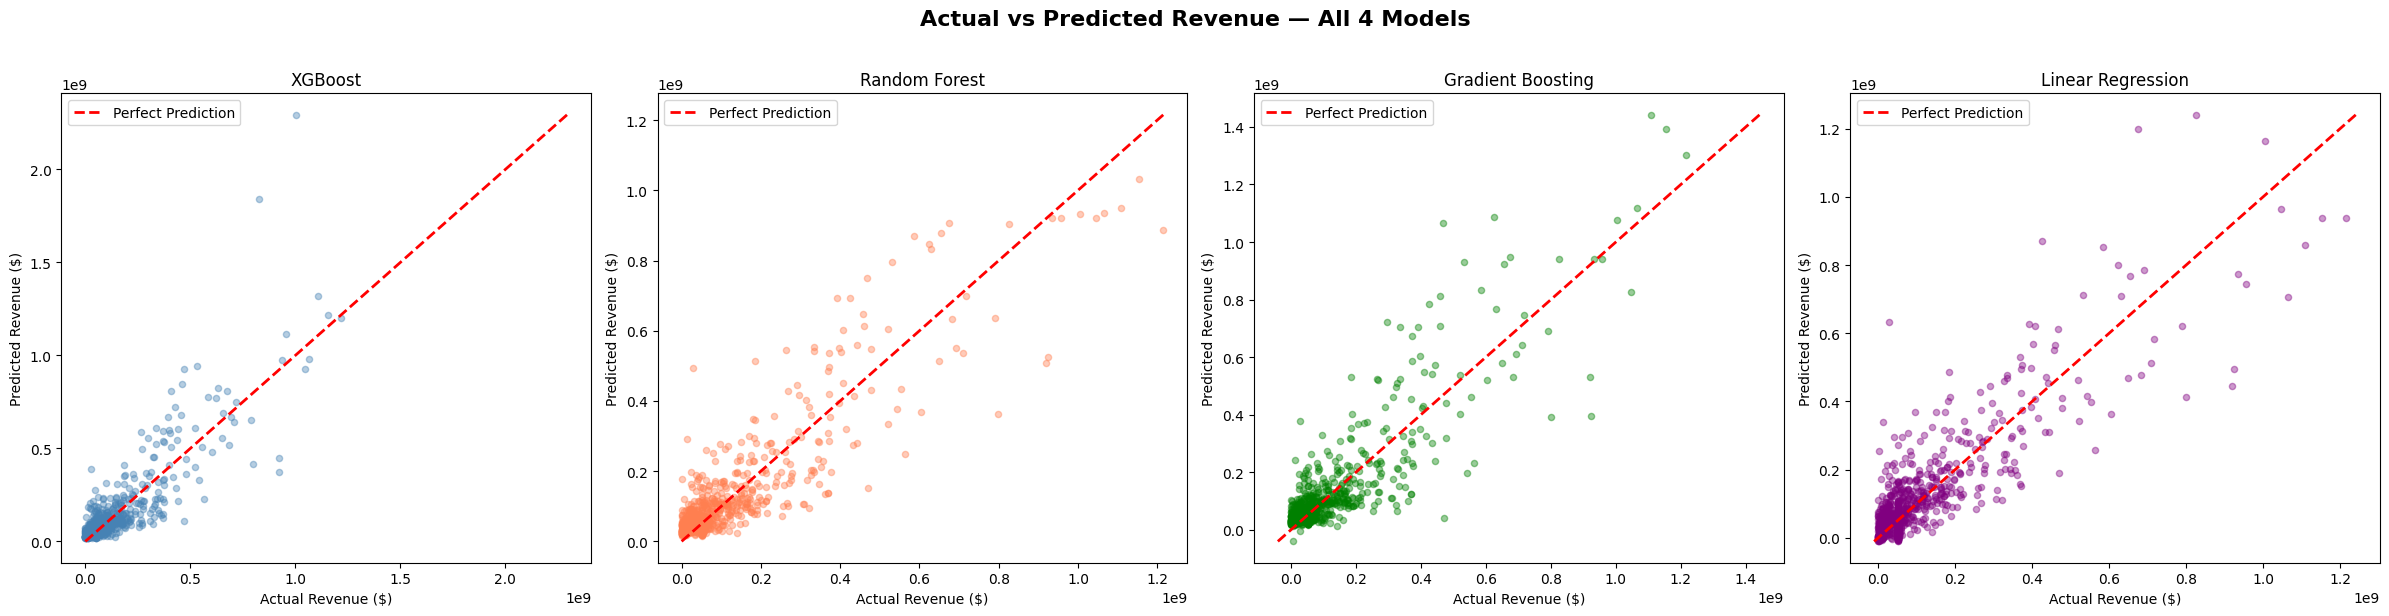

In [62]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(24, 6))  # ✅ 4 subplots for 4 models

colors = {
    'XGBoost':           'steelblue',
    'Random Forest':     'coral',
    'Gradient Boosting': 'green',
    'Linear Regression': 'purple'
}

# ✅ Rebuild predictions with matching Title Case keys
predictions_titled = {
    'XGBoost':           predictions['xgboost'],
    'Random Forest':     predictions['random forest'],
    'Gradient Boosting': predictions['gradient boosting'],
    'Linear Regression': predictions['linear regression'],
}

for ax, (name, y_pred) in zip(axes, predictions_titled.items()):
    ax.scatter(Y_test, y_pred, alpha=0.4, color=colors[name], s=20)
    
    min_val = min(Y_test.min(), y_pred.min())
    max_val = max(Y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Revenue ($)')
    ax.set_ylabel('Predicted Revenue ($)')
    ax.set_title(f'{name}')
    ax.legend()

plt.suptitle('Actual vs Predicted Revenue — All 4 Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

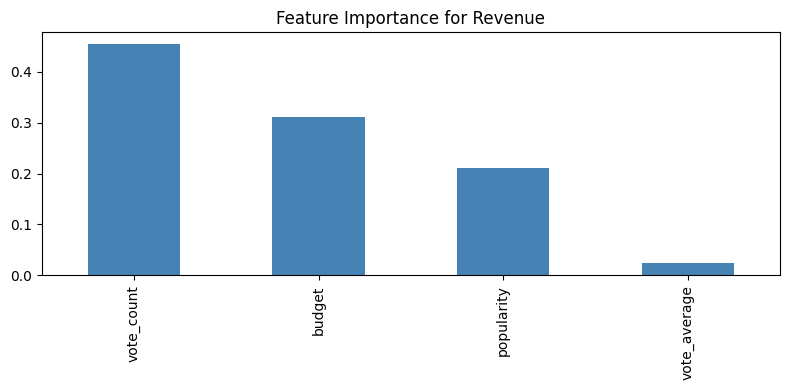

In [63]:
feat_imp = pd.Series(model.feature_importances_, index=features)\
             .sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance for Revenue')
plt.tight_layout()
plt.show()


In [64]:
new_movies = pd.DataFrame({
    'budget':       [150_000_000, 200_000_000, 50_000_000],
    'popularity':   [50.0,        120.0,        20.0],
    'vote_count':   [1000,        5000,         300],
    'vote_average': [7.5,         8.5,          6.0]
})

new_movies['predicted_revenue'] = model.predict(new_movies)

# format nicely
new_movies['predicted_revenue'] = new_movies['predicted_revenue'].apply(
    lambda x: f"${x:,.0f}"
)

print(new_movies[['budget', 'popularity', 'vote_average', 'predicted_revenue']])

      budget  popularity  vote_average predicted_revenue
0  150000000        50.0           7.5      $300,220,080
1  200000000       120.0           8.5      $911,338,138
2   50000000        20.0           6.0       $76,652,462


In [65]:
pickle.dump(models['Random Forest'], open('artifacts/random_forest.pkl', 'wb'))